In [1]:
# =============================================================================
# File:        timescale_analysis
# Author:      Orhan Soyuhos
# Last Modified: 05/16/2026
#
# Description:
#   Example code to calculate intrinsic neural timescales from example
#   spiking data.
# =============================================================================

# Setup

In [2]:
import os

# Resolve the path relative to this notebook so it is portable.
try:
    _here = os.path.dirname(os.path.abspath(__file__))
except NameError:  # __file__ is undefined inside Jupyter
    _here = os.getcwd()

data_path = os.path.normpath(os.path.join(_here, '..', 'data'))
print(f'Using data_path = {data_path}')

Using data_path = c:\Users\Orhan\Box\Macbook_backup\Xiaomo_lab\Projects\_Others\intrinsic-neural-timescales-main\data


In [3]:
region_name = 'RegionA'
bin_size = 10
maxTimeLag = 30 # maxtimelag for autocorrelation analysis
monkey_name = 'X'

# Import Libraries

In [4]:
import sys
import glob
import random
import math
import json

import pandas as pd
import numpy as np

from tqdm import tqdm

import scipy.io as sio
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import wilcoxon
from scipy.stats import norm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from statsmodels.formula.api import ols
import statsmodels.api as sm

from itertools import combinations
import itertools

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [6]:
seed_n = 42 # random seed 42
np.random.seed(seed_n)
random.seed(seed_n) 

# Import helpers

Pipeline helpers live in the local `helpers/` package (mirrors the MATLAB `helper_fun/` layout). Run the notebook from the `Python/` folder so `helpers` is importable.

In [7]:
from helpers import (
    calculate_spike_train,
    demean_neural_data,
    autocorr,
    fit_exponential_decay,
    default_fig_settings,
    plot_autocorr_trials,
    each_neuron_autocorr,
    plot_tau_values,
    plot_r_squared_values,
)

# Import the dataset

In [8]:
# Load the .mat file
file = os.path.join(data_path, 'example_spike_data.mat')
data = sio.loadmat(file)

# Select spike counts
neural_data = data['Spike_neu']
print(f'(Neurons, Conditions) --> {neural_data.shape}')

(Neurons, Conditions) --> (38, 200)


## Calculate spike counts for control condition

In [9]:
trial_start, trial_end = -300, 1000 
spike_counts = []

for neuron_data in neural_data:
    each_neuron_ts, each_neuron_spike = [], []

    # Iterate over the 96 unique trial types
    for idx_uniqueTrial, uniqueTrials_data in enumerate(neuron_data):
        if idx_uniqueTrial > 95:
            continue

        for trial_data in uniqueTrials_data:
            timestamps = trial_data[0][0]
            spike_train = calculate_spike_train(timestamps, bin_size, trial_start, trial_end)

            each_neuron_ts.append(timestamps)
            each_neuron_spike.append(spike_train)

    spike_counts.append(each_neuron_spike)

spike_counts = np.array(spike_counts)
print(f'(Neurons, Trials, Time points) --> {spike_counts.shape}')

(Neurons, Trials, Time points) --> (38, 1002, 131)


## Select baseline period

In [10]:
baseline_start, baseline_end = 0, 30 # The first 300 ms 
baseline_spike = spike_counts[:, :, baseline_start:baseline_end]
print(f'(Neurons, Trials, Time points) --> {baseline_spike.shape}')

(Neurons, Trials, Time points) --> (38, 1002, 30)


## Demean data

In [11]:
# 'trials' or 1: Demean across trials.
baseline_spike = demean_neural_data(baseline_spike, axis='trials')

------------------------------------------------------------------------------------------------------------------------

# Autocorrelation

In [12]:
# Depends on the length of the baseline period
maxTimeLag = baseline_spike.shape[2]

# Function call
stat = autocorr(baseline_spike, maxTimeLag)

# Shapes
ac = np.array(stat['autocorr'])
ac_log = np.array(stat['autocorr_log'])
ac.shape, ac_log.shape

c:\Users\Orhan\Box\Macbook_backup\Xiaomo_lab\Projects\_Others\intrinsic-neural-timescales-main\Python\helpers\autocorrelation.py:106: RuntimeWarning: invalid value encountered in log10
  autocorr_perNeuron_log = np.log10(autocorr_perNeuron)


((38, 30), (38, 30))

## Figures

In [13]:
default_fig_settings()

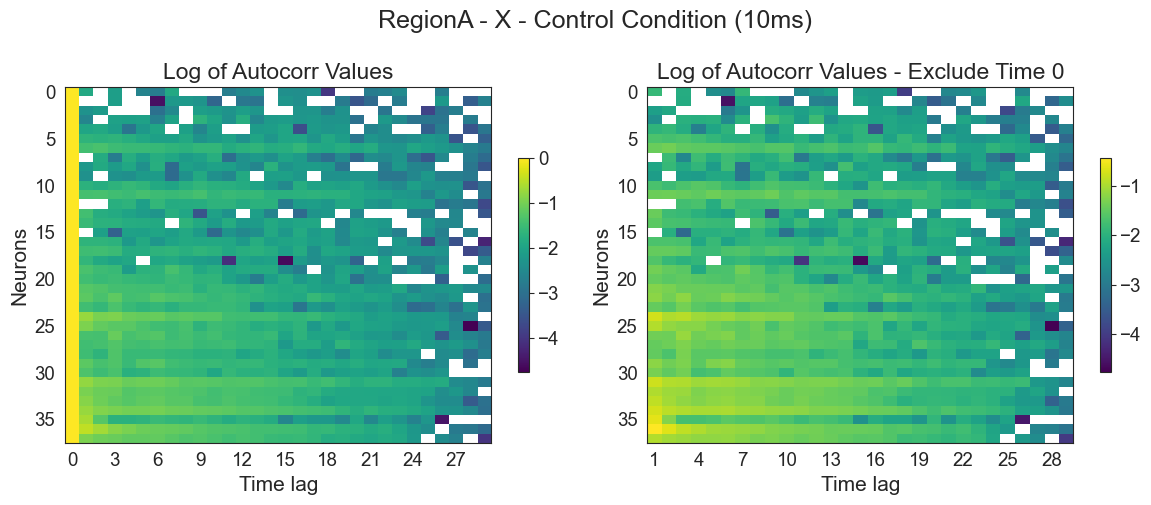

In [14]:
plot_autocorr_trials(region_name, monkey_name, ac_log, 'Control', bin_size)

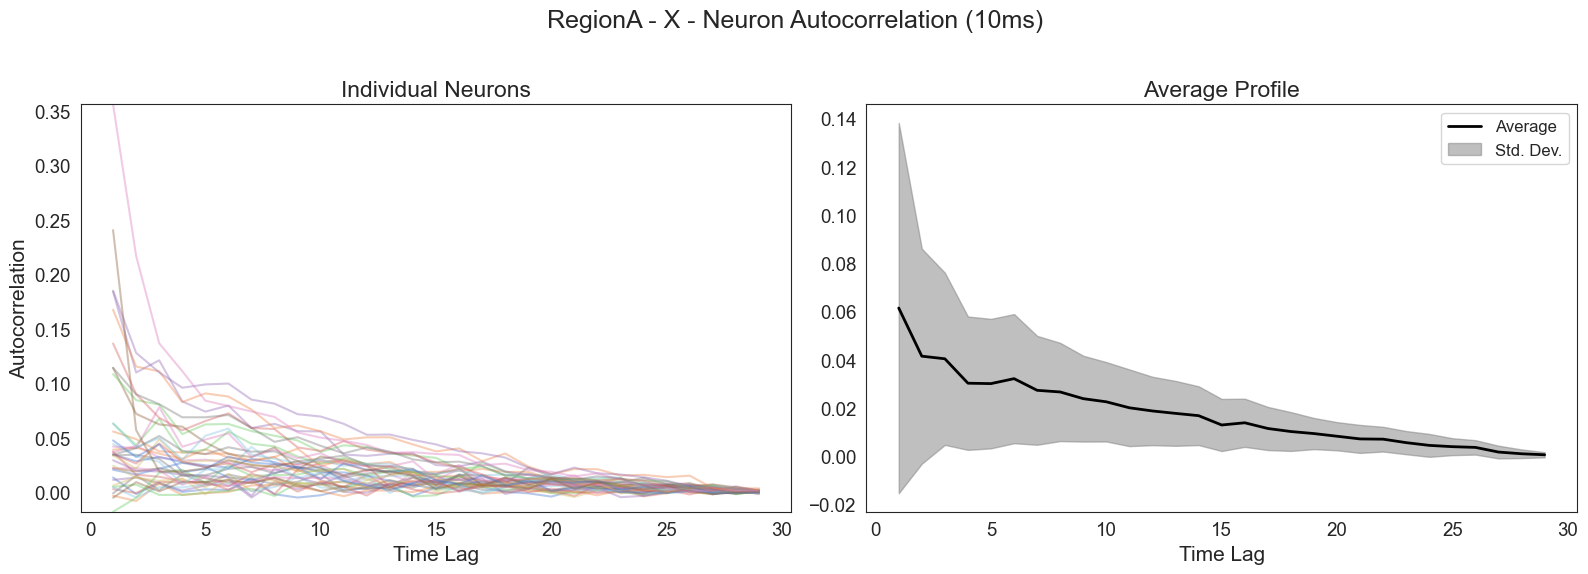

In [15]:
each_neuron_autocorr(ac, region_name, monkey_name, bin_size)

# Exponential decay fitting

## Individual fits

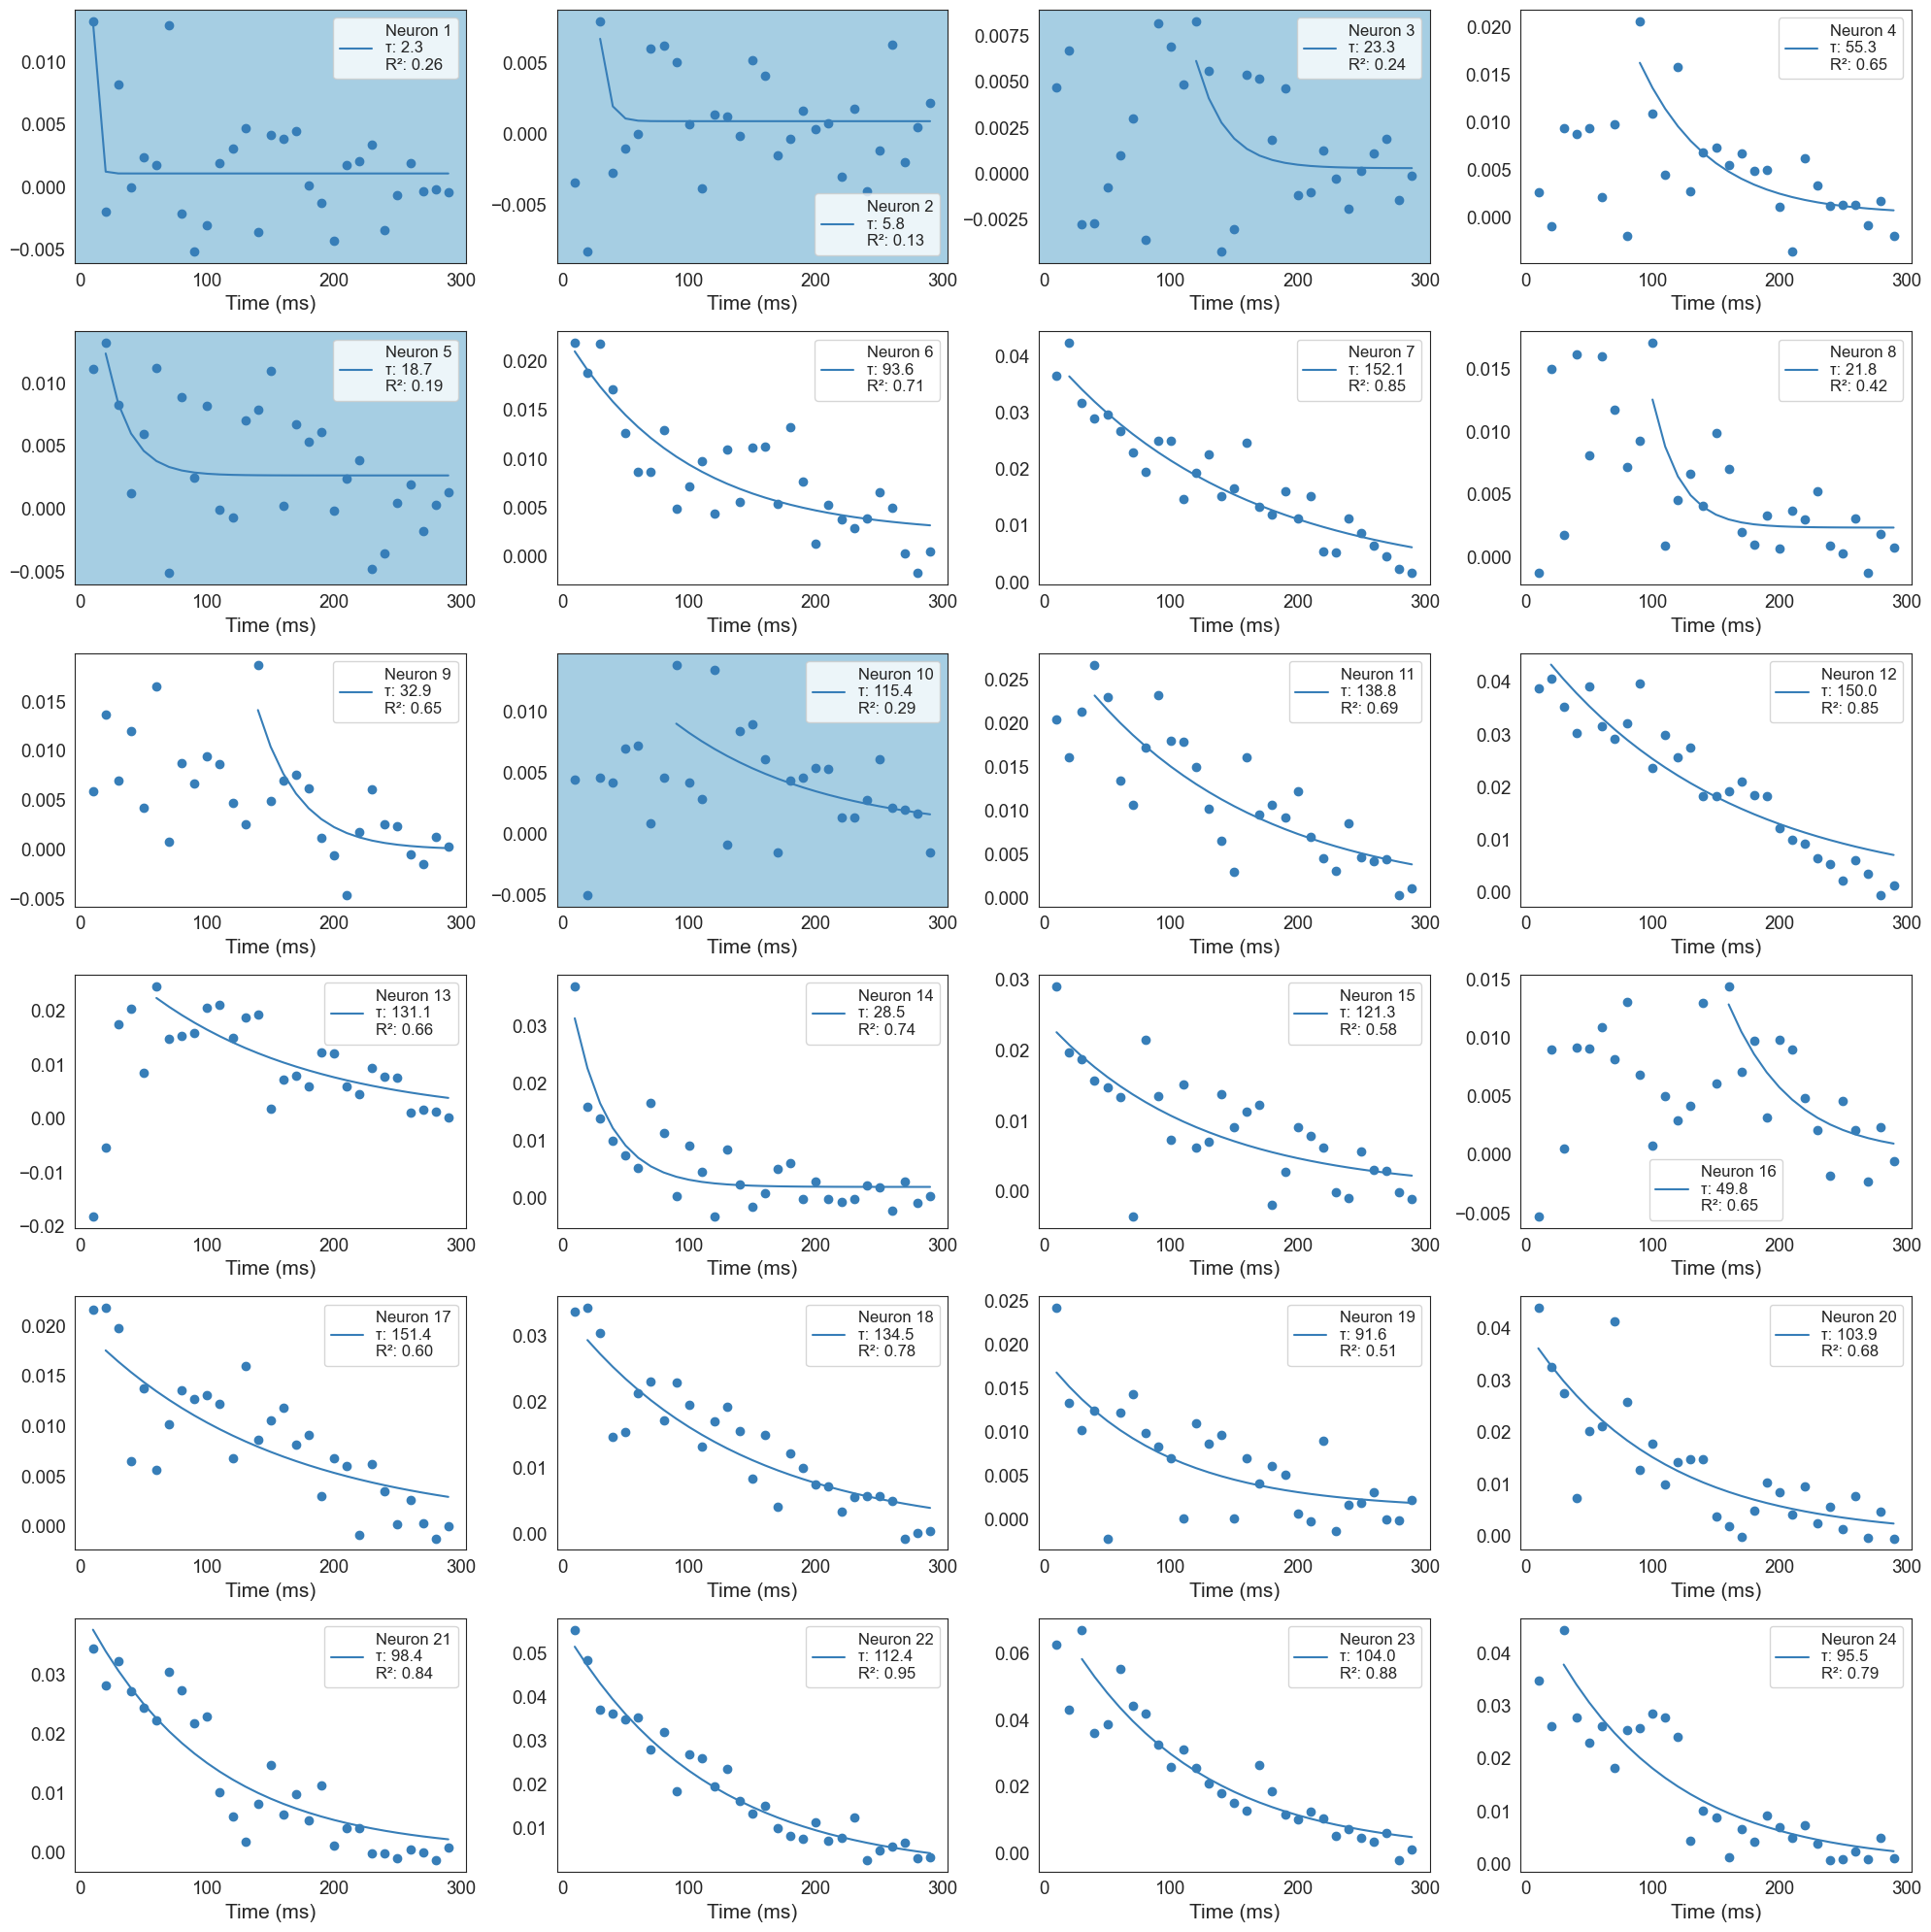

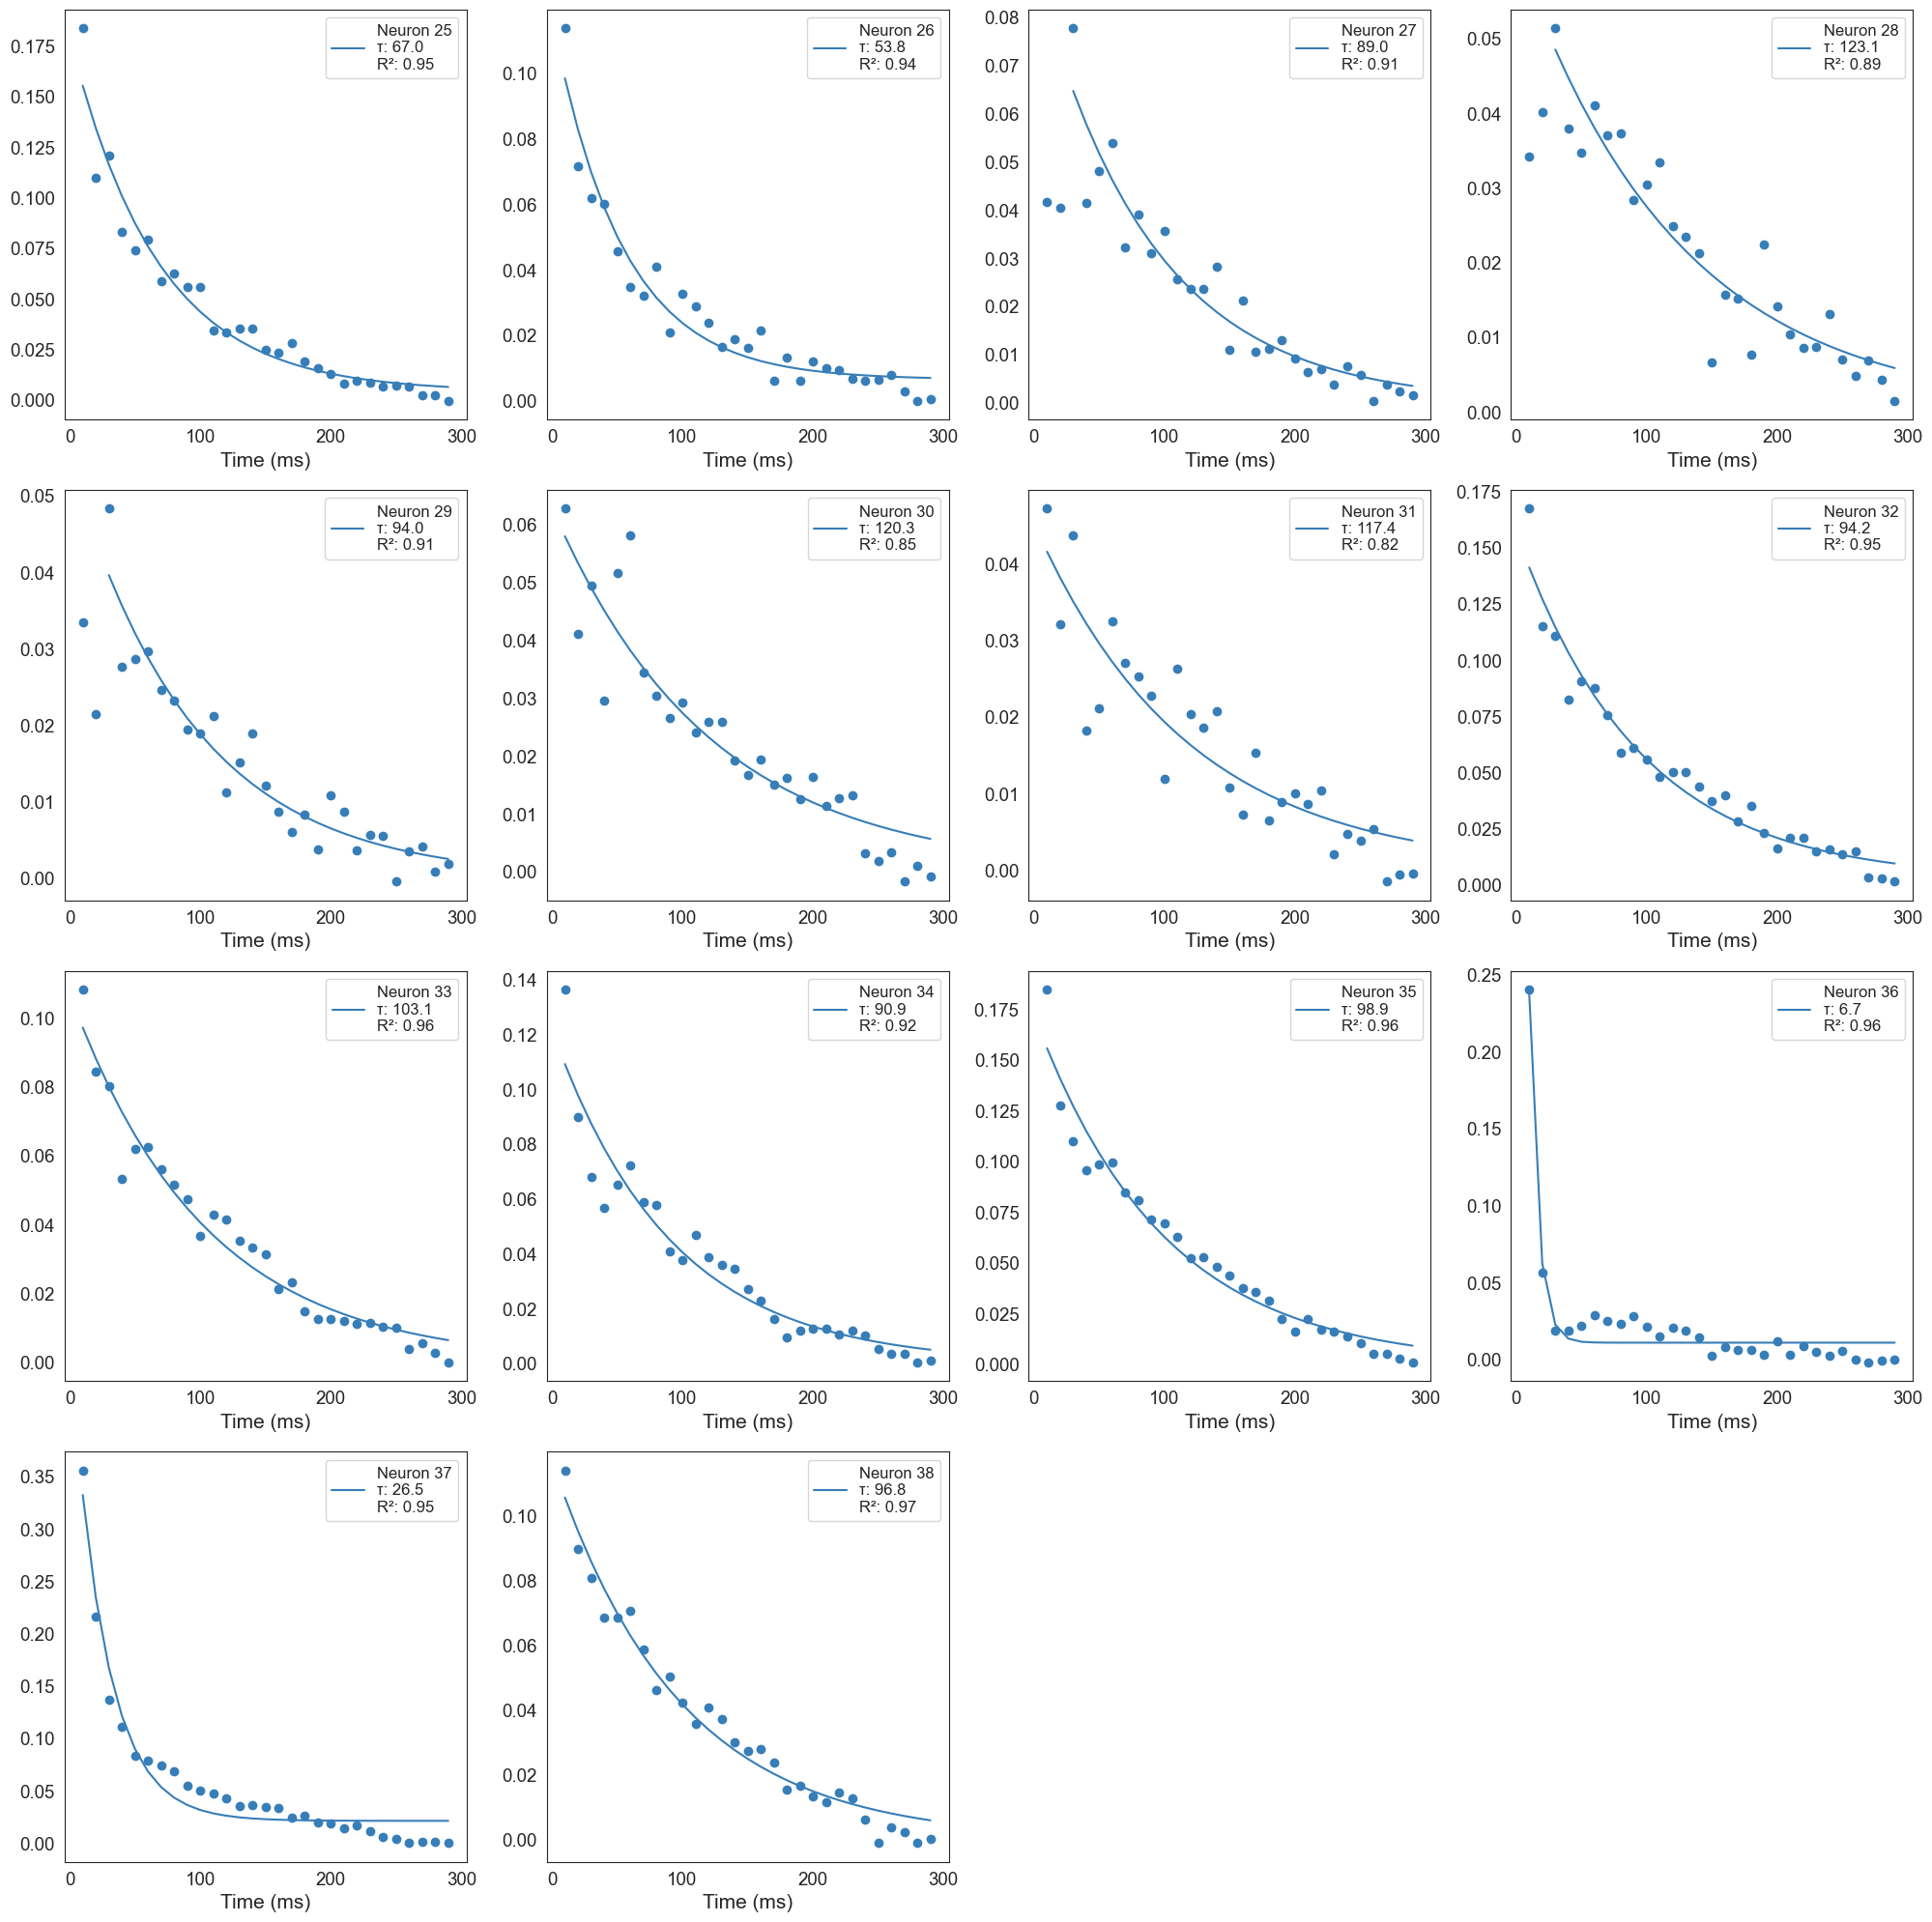

In [16]:
# Ideally R2 threshold has to be at least 0.3. 
# R2 values for the plots with blue background are below the threshold.
r2_threshold = 0.3
tau_values, r2_control, aics_control, bics_control = fit_exponential_decay(ac, bin_size, r2_threshold=r2_threshold)

## R2 values

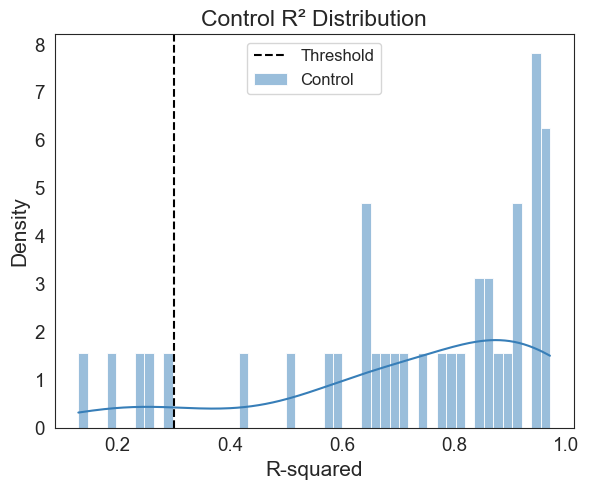

In [17]:
plot_r_squared_values(r2_control, 'Control', bins=50, r2_threshold=r2_threshold)

## Timescale values

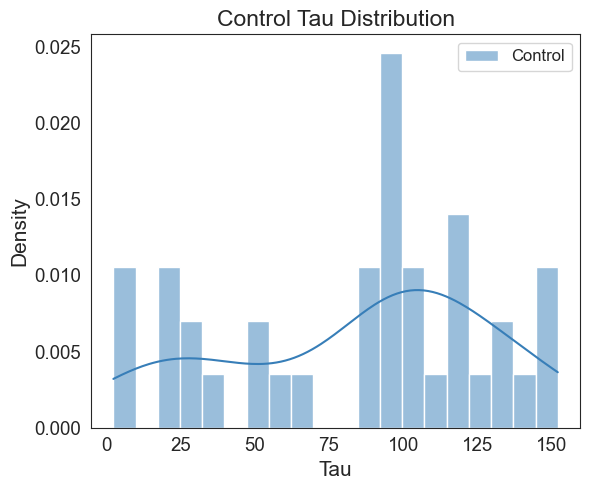

In [18]:
plot_tau_values(tau_values, 'Control', bins=20)

In [19]:
!jupyter nbconvert --to script timescale_analysis.ipynb

[NbConvertApp] Converting notebook timescale_analysis.ipynb to script
[NbConvertApp] Writing 4950 bytes to timescale_analysis.py
